# CONSOLIDATE

Consolidate crime and income using county and year

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

pd.set_option('display.max_columns', None)

MN income data = mn_income_clean.csv
MN crime data = mn_crime_clean.csv

In [9]:
mn_income = pd.read_csv("mn_income_clean_2025pred.csv", delimiter=',')
mn_crime = pd.read_csv("mn_crime_clean.csv", delimiter=',')
mn_crime_trend = pd.read_excel("MNHistoricalCrimeIndex 2025.xlsx")

mn_income.columns = mn_income.columns.str.lower()
mn_crime.columns = mn_crime.columns.str.lower()
mn_crime_trend.columns = mn_crime_trend.columns.str.lower()
mn_crime_trend.head(1)

,index year,year population,crime index total,murder,rape,robbery,aggravated assault,burglary,larceny,motor vehicle theft,arson,crime rate,unnamed: 12
0,1936,2563953,16753,38,101,788,274,4778,7203,3571,0,654.6,653.405113


In [11]:
# merge all data into one data frame
mn_crime_vs_income = mn_crime.merge(
    mn_income,
    on=["county", "year"]
    # how="left"      # or 'inner', depending on what you want
)

mn_crime_vs_income['crime_rate_per_1000'] = (
    mn_crime_vs_income['group a total'] / mn_crime_vs_income['county population'] * 1000
)

mn_crime_vs_income.head()
mn_crime_vs_income.to_csv("mn_income_merged.csv", index=False)

_MN Crime Index Total and Population Total by Year (Post-2001)_

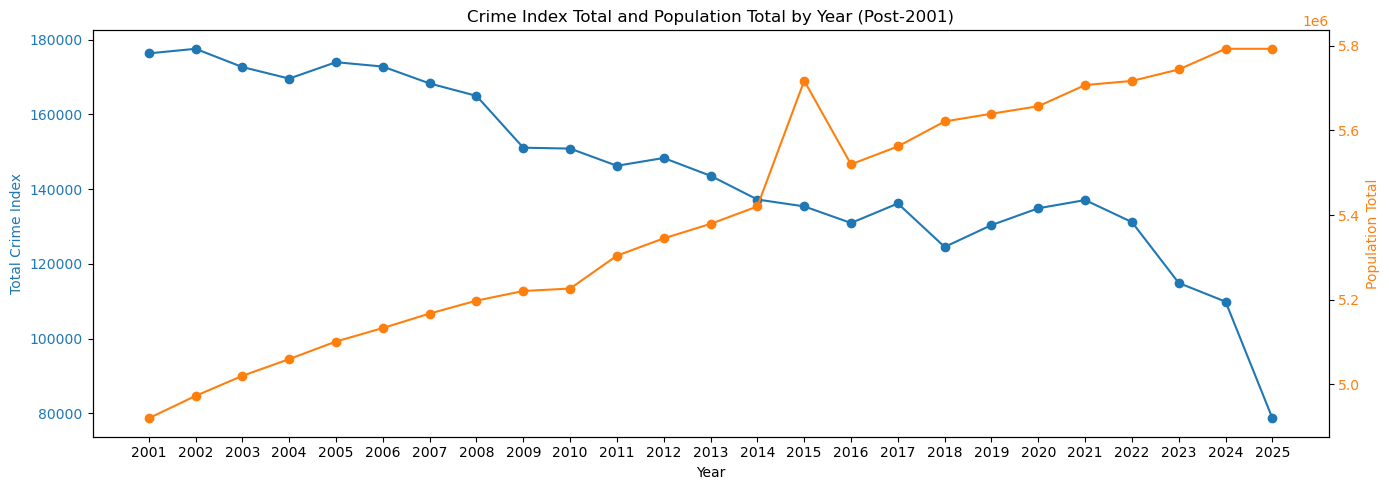

In [14]:
mn_crime_trend_total = (
    mn_crime_trend[mn_crime_trend['index year'] > 2000]
    .groupby('index year')[['crime index total', 'year population']]
    .sum()
)

# Create primary axis
fig, ax1 = plt.subplots(figsize=(14,5))

# Plot crime index on left y-axis
ax1.plot(
    mn_crime_trend_total.index,
    mn_crime_trend_total['crime index total'],
    marker='o',
    color='tab:blue',
    label='Crime Index Total'
)
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Crime Index', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create secondary axis for population
ax2 = ax1.twinx()
ax2.plot(
    mn_crime_trend_total.index,
    mn_crime_trend_total['year population'],
    marker='o',
    color='tab:orange',
    label='Population Total'
)
ax2.set_ylabel('Population Total', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Crime Index Total and Population Total by Year (Post-2001)')
plt.xticks(mn_crime_trend_total.index)
plt.tight_layout()
plt.show()

_MN Crime Type Distribution per Year_

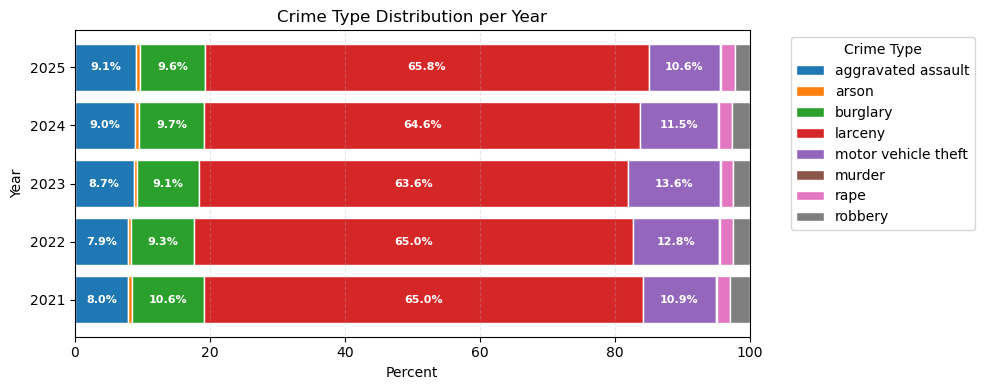

In [12]:
mn_crime_trend_total = (
    mn_crime_trend[mn_crime_trend['index year'] > 2000]
    .groupby('index year')[['crime index total', 'year population']]
    .sum()
)

mn_crime_after_2021 = mn_crime_trend[mn_crime_trend["index year"] > 2020]

crime_cols = [
    "murder", "rape", "robbery", "aggravated assault",
    "burglary", "larceny", "motor vehicle theft", "arson"
]

df_long = mn_crime_after_2021.melt(
    id_vars=["index year"],
    value_vars=crime_cols,
    var_name="crime_type",
    value_name="sum"
)

# Pivot: rows = years, columns = crime types
pivot = df_long.pivot(index="index year", columns="crime_type", values="sum")

# Convert to percent per year (row)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 4))

# Track left position for stacking
left = [0] * len(pivot_pct)

for crime in pivot_pct.columns:
    values = pivot_pct[crime]
    
    # Draw each stacked segment
    bars = plt.barh(
        pivot_pct.index,
        values,
        left=left,
        label=crime,
        edgecolor="white"
    )
    
    # Add percent labels inside each bar section
    for bar, pct in zip(bars, values):
        if pct > 3:   # show labels only if large enough to be readable
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=8,
                fontweight="bold"
            )
    
    # Update left positions for stacking
    left = left + values

plt.xlabel("Percent")
plt.ylabel("Year")
plt.title("Crime Type Distribution per Year")

plt.xlim(0, 100)
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Observation: _this chart displays how different categories of crime contribute to the total crime share each year from 2021 to 2025.
Larceny prevention, since it is the core driver of crime totals, every year consistently making up 64–66% of all crime — by far the largest crime category. Motor vehicle theft is the second-largest category, hovering around 10–13%. Aggravated assault remains stable around 8–9%. Burglary gradually declines from ~0.6% in 2021 to 9.1–9.6% in later years._


_Income vs Crime Rate per 1,000 (Colored by Income)_

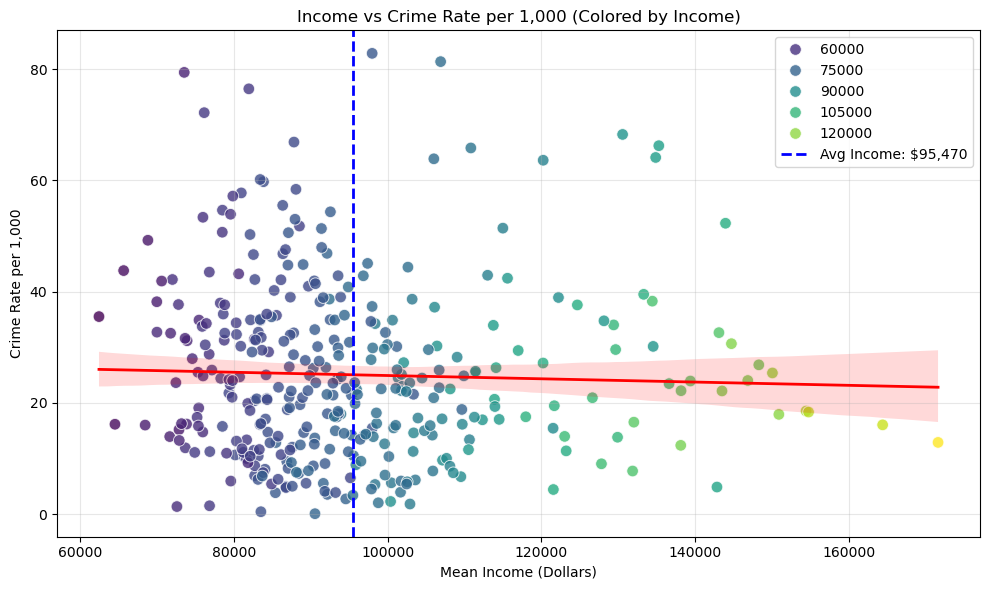

In [15]:
# Calculate average income

avg_income = mn_crime_vs_income['mean income (dollars)'].mean()
median_income = mn_crime_vs_income['median income (dollars)'].median()
plt.figure(figsize=(10,6))

# Scatter with color mapped to income
sns.scatterplot(
    data=mn_crime_vs_income,
    x='mean income (dollars)',
    y='crime_rate_per_1000',
    hue='median income (dollars)',
    palette='viridis',
    s=70,
    alpha=0.8
)

# Regression line
sns.regplot(
    data=mn_crime_vs_income,
    x='mean income (dollars)',
    y='crime_rate_per_1000',
    scatter=False,
    line_kws={'color':'red', 'linewidth':2}
)

# Add vertical line for average income
plt.axvline(avg_income, color='blue', linestyle='--', linewidth=2, label=f'Avg Income: ${avg_income:,.0f}')

plt.title('Income vs Crime Rate per 1,000 (Colored by Income)')
plt.xlabel('Mean Income (Dollars)')
plt.ylabel('Crime Rate per 1,000')
plt.legend()  # show the average income label
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This scatterplot compares mean income and crime rate, with every point representing a county.
Crime values vary widely across the income spectrum.
Income is not a strong predictor of crime rate by itself.
While poorer counties tend to have somewhat higher crime, the wide spread suggests other factors (population density, urbanization, policing, housing instability, substance abuse rates, etc.) play larger roles.

- The regression line shows a very slight negative slope:
- Higher income → Slightly lower crime, but the effect is weak.
- Points are widely scattered, meaning income alone does not strongly predict crime rates.
- A dashed vertical line marks the average Minnesota mean income is 95,470.

In [17]:
mn_crime_vs_income.head(5)

,county,county population,statistic,aggravated assault,all other larceny,animal cruelty,arson,assisting or promoting prostitution,betting/wagering,bribery,burglary/breaking & entering,counterfeiting/forgery,credit card/automated teller machine fraud,destruction/damage/vandalism of property,drug equipment violations,drug/narcotic violations,embezzlement,extortion/blackmail,false pretenses/swindle/confidence game,fondling,gambling equipment violation,hacking/computer invasion,"human trafficking, commercial sex acts","human trafficking, involuntary servitude",identity theft,impersonation,incest,intimidation,kidnapping/abduction,motor vehicle theft,murder & non-negligent manslaughter,negligent manslaughter,operating/promoting/assisting gambling,pocket-picking,pornography/obscene material,prostitution,purchasing prostitution,purse-snatching,rape,robbery,sexual assault with an object,shoplifting,simple assault,sodomy,sports tampering,statutory rape,stolen property offenses,theft from building,theft from coin-operated machine or device,theft from motor vehicle,theft of motor vehicle parts or accessories,weapon law violations,welfare fraud,wire fraud,group a total,year,mean income (dollars),median income (dollars),total,"$10,000 to $14,999","$100,000 to $149,999","$15,000 to $24,999","$150,000 to $199,999","$200,000 or more","$25,000 to $34,999","$35,000 to $49,999","$50,000 to $74,999","$75,000 to $99,999",household income in the past 12 months,"less than $10,000",crime_rate_per_1000
0,aitkin,15849.0,actual,7.0,106.0,1.0,0.0,0.0,0.0,0.0,57.0,8.0,3.0,113.0,41.0,124.0,0.0,0.0,16.0,1.0,0.0,0.0,0.0,0.0,44.0,2.0,0.0,26.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,3.0,52.0,3.0,0.0,0.0,2.0,2.0,0.0,17.0,11.0,18.0,0.0,1.0,694.0,2021,65646.0,50900.0,6595.0,0.065,0.122,0.103,0.037,0.029,0.111,0.159,0.193,0.127,0.315,0.055,43.788252
1,anoka,363957.0,actual,404.0,1332.0,73.0,38.0,0.0,0.0,0.0,580.0,295.0,428.0,1515.0,399.0,968.0,8.0,13.0,405.0,151.0,0.0,3.0,3.0,1.0,441.0,231.0,0.0,217.0,28.0,593.0,1.0,1.0,1.0,101.0,47.0,2.0,0.0,28.0,99.0,89.0,4.0,1326.0,961.0,15.0,0.0,0.0,221.0,346.0,0.0,1133.0,756.0,246.0,1.0,39.0,13543.0,2021,106117.0,88680.0,132559.0,0.019,0.224,0.044,0.114,0.091,0.058,0.099,0.169,0.160,0.306,0.023,37.210440
2,becker,34734.0,actual,94.0,132.0,3.0,1.0,0.0,0.0,0.0,85.0,41.0,21.0,160.0,108.0,321.0,0.0,0.0,40.0,23.0,0.0,0.0,0.0,0.0,36.0,4.0,0.0,82.0,7.0,77.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,4.0,18.0,5.0,2.0,149.0,212.0,2.0,0.0,0.0,22.0,71.0,0.0,36.0,14.0,24.0,1.0,0.0,1799.0,2021,88527.0,64296.0,13780.0,0.040,0.151,0.081,0.049,0.061,0.084,0.132,0.195,0.160,0.312,0.047,51.793632
3,beltrami,47851.0,actual,95.0,375.0,13.0,9.0,0.0,0.0,0.0,159.0,85.0,74.0,416.0,150.0,372.0,7.0,3.0,92.0,33.0,0.0,2.0,1.0,0.0,55.0,6.0,0.0,239.0,14.0,78.0,2.0,2.0,0.0,1.0,11.0,0.0,6.0,4.0,26.0,17.0,2.0,463.0,403.0,11.0,0.0,0.0,45.0,139.0,0.0,229.0,55.0,104.0,2.0,0.0,3800.0,2021,73531.0,55910.0,17555.0,0.056,0.138,0.094,0.054,0.046,0.087,0.144,0.173,0.141,0.310,0.067,79.413178
4,benton,32151.0,actual,22.0,163.0,1.0,1.0,0.0,0.0,0.0,53.0,27.0,13.0,143.0,36.0,66.0,0.0,1.0,32.0,10.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,65.0,0.0,34.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,1.0,0.0,40.0,101.0,2.0,0.0,0.0,5.0,57.0,0.0,111.0,24.0,17.0,1.0,0.0,1039.0,2021,80336.0,65529.0,16351.0,0.023,0.171,0.057,0.063,0.035,0.080,0.161,0.181,0.175,0.363,0.052,32.316258


In [21]:
mn_crime_vs_income_2024 = mn_crime_vs_income[mn_crime_vs_income["year"] == 2024]
mn_crime_vs_income_2024.head(1)

,county,county population,statistic,aggravated assault,all other larceny,animal cruelty,arson,assisting or promoting prostitution,betting/wagering,bribery,burglary/breaking & entering,counterfeiting/forgery,credit card/automated teller machine fraud,destruction/damage/vandalism of property,drug equipment violations,drug/narcotic violations,embezzlement,extortion/blackmail,false pretenses/swindle/confidence game,fondling,gambling equipment violation,hacking/computer invasion,"human trafficking, commercial sex acts","human trafficking, involuntary servitude",identity theft,impersonation,incest,intimidation,kidnapping/abduction,motor vehicle theft,murder & non-negligent manslaughter,negligent manslaughter,operating/promoting/assisting gambling,pocket-picking,pornography/obscene material,prostitution,purchasing prostitution,purse-snatching,rape,robbery,sexual assault with an object,shoplifting,simple assault,sodomy,sports tampering,statutory rape,stolen property offenses,theft from building,theft from coin-operated machine or device,theft from motor vehicle,theft of motor vehicle parts or accessories,weapon law violations,welfare fraud,wire fraud,group a total,year,mean income (dollars),median income (dollars),total,"$10,000 to $14,999","$100,000 to $149,999","$15,000 to $24,999","$150,000 to $199,999","$200,000 or more","$25,000 to $34,999","$35,000 to $49,999","$50,000 to $74,999","$75,000 to $99,999",household income in the past 12 months,"less than $10,000",crime_rate_per_1000
258,anoka,378279.0,actual,357.0,1077.0,29.0,26.0,0.0,1.0,0.0,422.0,189.0,353.0,1029.0,0.0,551.0,8.0,25.0,512.0,123.0,1.0,3.0,20.0,1.0,273.0,181.0,0.0,253.0,15.0,369.0,9.0,3.0,1.0,54.0,66.0,2.0,1.0,23.0,91.0,56.0,2.0,1873.0,959.0,9.0,0.0,0.0,140.0,295.0,1.0,524.0,126.0,178.0,11.0,37.0,10279.0,2024,120234.0,100812.0,140222.0,0.014,0.216,0.04,0.147,0.14,0.035,0.09,0.157,0.136,0.314,0.024,27.173065


In [23]:
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Compute yearly averages
# -----------------------------
yearly_avg = mn_crime_vs_income.groupby("year").agg({
    "county population": "sum",    
    "mean income (dollars)": "mean",
    "group a total": "mean",
    "crime_rate_per_1000": "mean"
}).reset_index()

print(yearly_avg)




   year  county population  mean income (dollars)  group a total  \
0  2021          5703654.0           84163.197674    3213.953488   
1  2022          5713291.0           91602.151163    3030.872093   
2  2023          5740384.0           95493.220930    2698.267442   
3  2024          4263544.0          119235.250000   11457.250000   
4  2025          5789338.0          106200.679070    1945.151163   

   crime_rate_per_1000  
0            31.923046  
1            27.752651  
2            23.620896  
3            32.469325  
4            15.560223  


avg_income =95470.16500000002,avg_crime=3110.2916666666665, avg_crime_rate:25.058876237682664 

Top 5 High-Risk Counties (Low Income + High Crime):

    county  mean income (dollars)  group a total
 st. louis              90157.800        8720.20
   stearns              94383.620        7715.60
blue earth              89940.680        3492.80
  beltrami              86482.525        3154.75


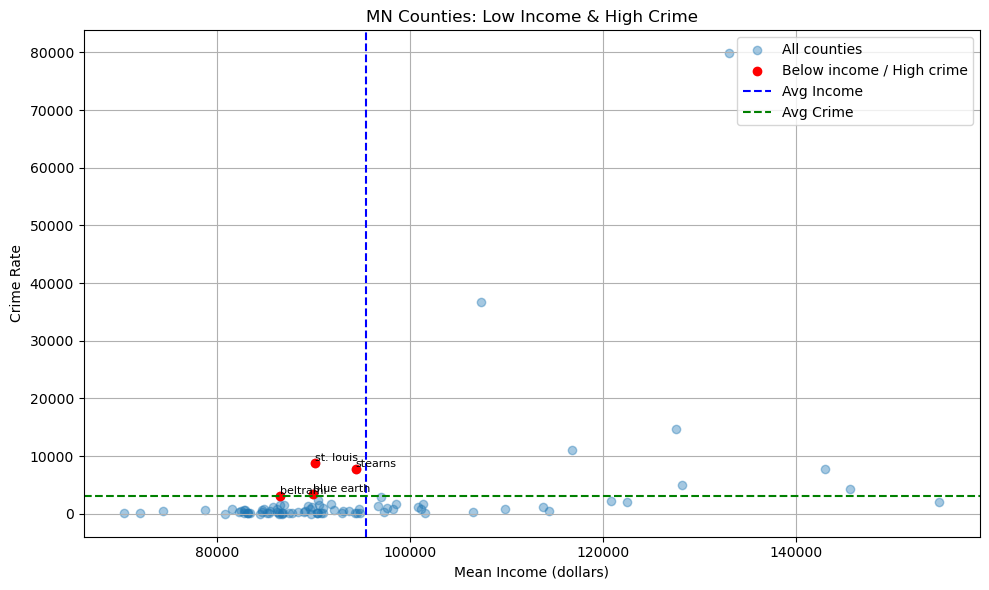

In [25]:
mn_crime_vs_income_means = (
    mn_crime_vs_income
    .groupby("county")
    .agg({
        "mean income (dollars)": "mean",
        "median income (dollars)": "mean",
        "group a total": "mean",
        "crime_rate_per_1000": "mean"
    })
    .reset_index()
)
avg_income = mn_crime_vs_income["mean income (dollars)"].mean()
median_income = mn_crime_vs_income["median income (dollars)"].mean()
avg_crime  = mn_crime_vs_income["group a total"].mean()
avg_crime_rate = mn_crime_vs_income["crime_rate_per_1000"].mean()

print(f"avg_income ={avg_income},avg_crime={avg_crime}, avg_crime_rate:{avg_crime_rate} ")
high_risk = mn_crime_vs_income_means[
    (mn_crime_vs_income_means["mean income (dollars)"] < avg_income) &
    (mn_crime_vs_income_means["group a total"] > avg_crime)
]
plt.figure(figsize=(10,6))

top10 = high_risk.sort_values("group a total", ascending=False).head(5)

print("\nTop 5 High-Risk Counties (Low Income + High Crime):\n")
print(top10[["county", "mean income (dollars)", "group a total"]].to_string(index=False))

plt.scatter(
    mn_crime_vs_income_means["mean income (dollars)"],
    mn_crime_vs_income_means["group a total"],
    alpha=0.4,
    label="All counties"
)

plt.scatter(
    high_risk["mean income (dollars)"],
    high_risk["group a total"],
    color="red",
    label="Below income / High crime"
)

plt.axvline(avg_income, color="blue", linestyle="--", label="Avg Income")
plt.axhline(avg_crime, color="green", linestyle="--", label="Avg Crime")
#plt.axhline(avg_crime_rate, color="black", linestyle="--", label=" crime rate")
plt.title("MN Counties: Low Income & High Crime")
plt.xlabel("Mean Income (dollars)")
plt.ylabel("Crime Rate")
plt.legend()
plt.grid(True)


# Add labels to TOP 5 counties

top5 = top10.head(5)

for _, row in top5.iterrows():
    plt.text(
        row["mean income (dollars)"],
        row["group a total"],
        row["county"],
        fontsize=8,
        ha="left",
        va="bottom"
    )
plt.tight_layout()
plt.show()



This plot highlights counties that fall into the high-risk quadrant:
- Income below state average
- Crime rate above state average

The top 5 counties in this category show both socioeconomic stress (low income) and public safety issues (high crime).

- _St. Louis County has an average income of around 90K but experiences a very high crime rate, making it the most pronounced outlier and a clear high-risk area._
- _Stearns County has an income of roughly 94K and a high crime rate, marking it as a significant crime hotspot compared to other counties._
- _Blue Earth County earns about 89K on average and shows a moderately high crime rate, placing it above the statewide crime average._
- _Beltrami County has one of the lower incomes at approximately $86,000 and an elevated crime rate, indicating that it is consistently among the at-risk counties in the state._